In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Загрузка данных
anime_df = pd.read_csv('anime.csv')
rating_df = pd.read_csv('rating.csv')

print(f"Загружено аниме: {anime_df.shape[0]}")
print(f"Загружено оценок: {rating_df.shape[0]}")

Загружено аниме: 12294
Загружено оценок: 7813737


In [3]:
# очистка данных: удаляем оценки -1 (это статус планирую посмотреть, а не оценка)
rating_df = rating_df[rating_df['rating'] != -1]
print(f"Оценок после удаления '-1': {rating_df.shape[0]}")

Оценок после удаления '-1': 6337241


In [4]:
# базовая фильтрация для ускорения SVD и улучшения качества
# датасет довольно большой, и "чистый SVD" может работать долго
# отсеем пользователей и аниме с оченб маленьким числом оценок
MIN_USER_RATINGS = 10  # мин оценок от пользователя
MIN_ANIME_RATINGS = 20 # мин оценок для аниме

user_counts = rating_df.groupby('user_id').size()
valid_users = user_counts[user_counts >= MIN_USER_RATINGS].index

anime_counts = rating_df.groupby('anime_id').size()
valid_anime = anime_counts[anime_counts >= MIN_ANIME_RATINGS].index

# фильтруем датафрейм
rating_filtered = rating_df[
    rating_df['user_id'].isin(valid_users) & 
    rating_df['anime_id'].isin(valid_anime)].copy()

print("После фильтрации")
print(f"  - Осталось оценок: {rating_filtered.shape[0]}")
print(f"  - Осталось пользователей: {rating_filtered['user_id'].nunique()}")
print(f"  - Осталось аниме: {rating_filtered['anime_id'].nunique()}")

После фильтрации
  - Осталось оценок: 6258472
  - Осталось пользователей: 55118
  - Осталось аниме: 6536


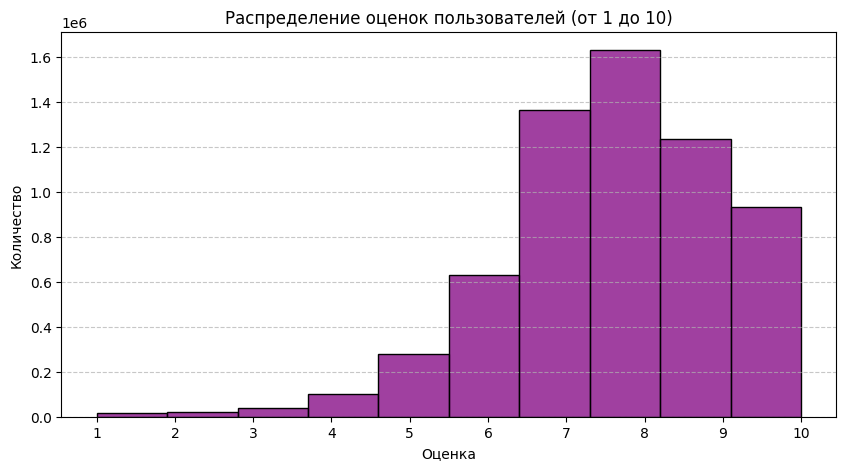

In [5]:
# визуализация распределения оценок (в этом датасете шкала от 1 до 10)
plt.figure(figsize=(10, 5))
sns.histplot(rating_filtered['rating'], bins=10, kde=False, color='purple')
plt.title('Распределение оценок пользователей (от 1 до 10)')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.xticks(range(1, 11))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


мини анализ графика:

шкала оценок от 1 до 10, а в MovieLens было от 1 до 5

самая популярная оценка это 8

левостороннее смещение

большинство оценок положительные, отрицательные оценки редкие

в задании написано, что нужно использовать чистый SVD, т.е. не из sklearn, а алгоритм FunkSVD

In [6]:
from sklearn.model_selection import train_test_split
import time

# разделяем данные на трейн и тест (80/20)
train_data, test_data = train_test_split(rating_filtered, test_size=0.2, random_state=42)
print(f"Train: {len(train_data)} оценок | Test: {len(test_data)} оценок")

Train: 5006777 оценок | Test: 1251695 оценок


In [7]:
# создаем маппинги (словари) для перевода ID в индексы массивов (от 0 до N)
user_ids = train_data['user_id'].unique()
anime_ids = train_data['anime_id'].unique()

user2idx = {u: i for i, u in enumerate(user_ids)}
idx2user = {i: u for u, i in user2idx.items()}

anime2idx = {a: i for i, a in enumerate(anime_ids)}
idx2anime = {i: a for a, i in anime2idx.items()}

n_users = len(user_ids)
n_anime = len(anime_ids)

print(f"Уникальных пользователей в train: {n_users}")
print(f"Уникальных аниме в train: {n_anime}")

Уникальных пользователей в train: 55118
Уникальных аниме в train: 6536


In [8]:
# реализация класса FunkSVD (матричная факторизация через SGD)
class FunkSVD:
    def __init__(self, n_factors=20, n_epochs=10, lr=0.01, reg=0.02):
        """
        n_factors: размерность латентного пространства (наш главный гиперпараметр)
        n_epochs: количество проходов по всем данным
        lr: learning rate (шаг градиентного спуска)
        reg: коэффициент L2-регуляризации (защита от переобучения)
        """
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg = reg
        
    def fit(self, train_df, user2idx, anime2idx, n_users, n_anime):
        self.n_users = n_users
        self.n_anime = n_anime
        
        # Глобальное среднее всех оценок
        self.global_mean = train_df['rating'].mean()
        
        # Инициализация параметров (Bias и Латентные векторы)
        self.bu = np.zeros(n_users)          # Смещение пользователя
        self.bi = np.zeros(n_anime)          # Смещение аниме
        self.pu = np.random.normal(0, 0.1, (n_users, self.n_factors)) # Вектор пользователя
        self.qi = np.random.normal(0, 0.1, (n_anime, self.n_factors)) # Вектор аниме
        
        # Преобразуем pandas в numpy-массивы для скорости
        users = train_df['user_id'].map(user2idx).values
        items = train_df['anime_id'].map(anime2idx).values
        ratings = train_df['rating'].values
        
        print(f"\nНачало обучения (эпох: {self.n_epochs}, факторов: {self.n_factors})...")
        
        # Стохастический градиентный спуск
        for epoch in range(self.n_epochs):
            start_time = time.time()
            # Перемешиваем данные в начале каждой эпохи
            shuffle_idx = np.random.permutation(len(train_df))
            users_sh = users[shuffle_idx]
            items_sh = items[shuffle_idx]
            ratings_sh = ratings[shuffle_idx]
            
            epoch_error = 0
            
            # Проходим по каждой оценке
            for u, i, r in zip(users_sh, items_sh, ratings_sh):
                # Формула предсказания: r_hat = mu + b_u + b_i + q_i * p_u
                pred = self.global_mean + self.bu[u] + self.bi[i] + np.dot(self.qi[i], self.pu[u])
                
                # Ошибка предсказания
                err = r - pred
                epoch_error += err**2
                
                # Обновление параметров (Градиентный спуск)
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                
                # Сохраняем старое значение pu для обновления qi
                pu_temp = self.pu[u].copy()
                self.pu[u] += self.lr * (err * self.qi[i] - self.reg * self.pu[u])
                self.qi[i] += self.lr * (err * pu_temp - self.reg * self.qi[i])
                
            rmse = np.sqrt(epoch_error / len(train_df))
            elapsed = time.time() - start_time
            print(f"  Epoch {epoch+1:2d}/{self.n_epochs} | RMSE: {rmse:.4f} | Time: {elapsed:.1f}s")
            
    def predict(self, u_idx, i_idx):
        # Если пользователь или аниме новые (не было в train), возвращаем global_mean
        if u_idx >= self.n_users or i_idx >= self.n_anime:
            return self.global_mean
            
        pred = self.global_mean + self.bu[u_idx] + self.bi[i_idx] + np.dot(self.qi[i_idx], self.pu[u_idx])
        # Ограничиваем диапазон от 1 до 10
        return max(1.0, min(10.0, pred))

In [9]:
# инициализируем модель с базовыми параметрами
# n_factors=20 - размерность скрытых признаков (например, "насколько аниме комедийное" или "насколько оно мрачное")
svd_model = FunkSVD(n_factors=20, n_epochs=5, lr=0.01, reg=0.02)

# запускаем обучение
svd_model.fit(train_data, user2idx, anime2idx, n_users, n_anime)

print("\nОбучение завершено")


Начало обучения (эпох: 5, факторов: 20)...
  Epoch  1/5 | RMSE: 1.2971 | Time: 41.4s
  Epoch  2/5 | RMSE: 1.2124 | Time: 40.9s
  Epoch  3/5 | RMSE: 1.1766 | Time: 40.7s
  Epoch  4/5 | RMSE: 1.1451 | Time: 40.9s
  Epoch  5/5 | RMSE: 1.1156 | Time: 40.9s

Обучение завершено


In [10]:
# возьмем случайного пользователя из теста
sample_user = test_data['user_id'].iloc[0]
sample_user_idx = user2idx.get(sample_user)

# найдем аниме, которые он оценил в тесте
user_test_ratings = test_data[test_data['user_id'] == sample_user]

print(f"Проверка работы SVD для пользователя ID: {sample_user}")
print("-" * 60)
print(f"{'Название аниме':<40} | {'Реальная':<8} | {'Предсказано':<10}")
print("-" * 60)

count = 0
for _, row in user_test_ratings.iterrows():
    anime_id = row['anime_id']
    actual_rating = row['rating']
    
    # получаем индекс аниме (если его нет в train, пропускаем)
    anime_idx = anime2idx.get(anime_id)
    if anime_idx is None:
        continue
        
    # предсказываем оценку
    pred_rating = svd_model.predict(sample_user_idx, anime_idx)
    
    # получаем название аниме (колонка 'name' с маленькой буквы!)
    anime_name = anime_df[anime_df['anime_id'] == anime_id]['name'].values
    title = anime_name[0][:38] if len(anime_name) > 0 else "Unknown"
    
    print(f"{title:<40} | {actual_rating:<8} | {pred_rating:<15.2f}")
    
    count += 1
    if count >= 15: # выведем первые 10 для наглядности
        break

Проверка работы SVD для пользователя ID: 38679
------------------------------------------------------------
Название аниме                           | Реальная | Предсказано
------------------------------------------------------------
Itazura na Kiss                          | 6        | 8.27           
Mitsu x Mitsu Drops                      | 7        | 7.02           
Hiyokoi (2012)                           | 7        | 7.47           
Kimi no Iru Machi: Tasogare Kousaten     | 6        | 7.91           
Tonari no Kaibutsu-kun                   | 8        | 8.17           
Uta no☆Prince-sama♪ Maji Love 2000%      | 9        | 8.01           
Diabolik Lovers                          | 6        | 6.27           
Kiniro no Corda: Primo Passo             | 9        | 7.97           
Kami nomi zo Shiru Sekai                 | 7        | 8.13           
Lovely★Complex                           | 9        | 8.40           
Chihayafuru                              | 8        | 8.31       

бебебебе

In [15]:
from surprise import SVD, Reader, Dataset
from surprise.model_selection import train_test_split as surprise_train_test_split
from surprise import accuracy
import time

print("Подготовка данных для библиотеки surprise")

# surprise требует свой формат reader с указанием шкалы оценок (1-10 для аниме)
reader = Reader(rating_scale=(1, 10))

# создаем датасет из нашего очищенного датафрейма rating_filtered
# surprise сам разделит на train/test, но мы используем наше разделение для честности
data = Dataset.load_from_df(
    rating_filtered[['user_id', 'anime_id', 'rating']], 
    reader
)

# разделяем на трейн и тест в тех же пропорциях с тем же random_state
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {trainset.n_ratings} оценок")
print(f"Размер тестовой выборки:  {len(testset)} оценок")
print(f"Уникальных пользователей: {trainset.n_users}")
print(f"Уникальных аниме:         {trainset.n_items}")

Подготовка данных для библиотеки surprise
Размер обучающей выборки: 5006777 оценок
Размер тестовой выборки:  1251695 оценок
Уникальных пользователей: 55118
Уникальных аниме:         6536


In [16]:
def evaluate_svd_model(model, testset, k=10, relevance_threshold=8):
    """
    Считает RMSE, MAE, Precision@K, Recall@K, NDCG@K для модели Surprise.
    """
    # метрики регрессии (RMSE, MAE) - встроенные в Surprise
    predictions = model.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)
    
    # метрики ранжирования (Precision, Recall, NDCG)
    # группируем тестовые данные по пользователям
    user_preds = {}
    user_relevant = {}
    
    for uid, iid, true_r, est, _ in predictions:
        if uid not in user_preds:
            user_preds[uid] = []
            user_relevant[uid] = []
        
        user_preds[uid].append((iid, est))
        if true_r >= relevance_threshold:
            user_relevant[uid].append(iid)
    
    precisions = []
    recalls = []
    ndcgs = []
    
    for uid in user_preds:
        relevant = set(user_relevant[uid])
        if not relevant:
            continue
        
        # сортируем предсказания по убыванию оценки и берем top-K
        user_preds[uid].sort(key=lambda x: x[1], reverse=True)
        top_k_items = [item[0] for item in user_preds[uid][:k]]
        
        hits = len(set(top_k_items).intersection(relevant))
        
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
        
        # NDCG
        dcg = sum([1 / np.log2(i + 2) for i, item in enumerate(top_k_items) if item in relevant])
        ideal_hits = min(len(relevant), k)
        idcg = sum([1 / np.log2(i + 2) for i in range(ideal_hits)])
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'Precision@10': np.mean(precisions) if precisions else 0,
        'Recall@10': np.mean(recalls) if recalls else 0,
        'NDCG@10': np.mean(ndcgs) if ndcgs else 0
    }

In [18]:
# запуск эксперимента с разной размерностью

n_factors_list = [10, 20, 50, 100]
results = []

print("Подбор гиперпараметра n_factors (библиотека surprise)")

for n_f in n_factors_list:
    print(f"\nОбучение SVD с n_factors = {n_f}")
    start_time = time.time()
    
    # Инициализируем модель Surprise SVD
    # n_factors - размерность латентного пространства
    # n_epochs - количество итераций SGD
    # lr_all - learning rate
    # reg_all - L2-регуляризация
    svd_model = SVD(
        n_factors=n_f, 
        n_epochs=20,
        lr_all=0.005, 
        reg_all=0.02,
        random_state=42
    )
    
    # обучаем
    svd_model.fit(trainset)
    elapsed = time.time() - start_time
    
    # считаем метрики
    metrics = evaluate_svd_model(svd_model, testset, k=10, relevance_threshold=8)
    metrics['n_factors'] = n_f
    metrics['train_time_sec'] = round(elapsed, 1)
    results.append(metrics)
    
    print(f"Выполнено за {elapsed:.1f} сек | RMSE: {metrics['RMSE']:.4f} | Precision@10: {metrics['Precision@10']:.4f} | NDCG@10: {metrics['NDCG@10']:.4f}")

# итоговая таблица
results_df = pd.DataFrame(results)
print("\n" + "~"*70)
print("Итоговая таблица:")
print(results_df[['n_factors', 'train_time_sec', 'RMSE', 'MAE', 'Precision@10', 'Recall@10', 'NDCG@10']].to_string(index=False))

Подбор гиперпараметра n_factors (библиотека surprise)

Обучение SVD с n_factors = 10
Выполнено за 31.0 сек | RMSE: 1.1288 | Precision@10: 0.6422 | NDCG@10: 0.9062

Обучение SVD с n_factors = 20
Выполнено за 32.3 сек | RMSE: 1.1246 | Precision@10: 0.6432 | NDCG@10: 0.9078

Обучение SVD с n_factors = 50
Выполнено за 37.5 сек | RMSE: 1.1248 | Precision@10: 0.6435 | NDCG@10: 0.9083

Обучение SVD с n_factors = 100
Выполнено за 46.0 сек | RMSE: 1.1263 | Precision@10: 0.6442 | NDCG@10: 0.9097

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Итоговая таблица:
 n_factors  train_time_sec     RMSE      MAE  Precision@10  Recall@10  NDCG@10
        10            31.0 1.128801 0.846923      0.642184   0.736209 0.906155
        20            32.3 1.124604 0.842671      0.643206   0.736877 0.907755
        50            37.5 1.124839 0.840722      0.643521   0.737153 0.908319
       100            46.0 1.126293 0.841241      0.644151   0.737405 0.909660


Разница между n_factors=10 и n_factors=100 составляет всего 0.0015 для RMSE статистически незначимо. Модель практически не улучшает качество предсказания при увеличении размерности.

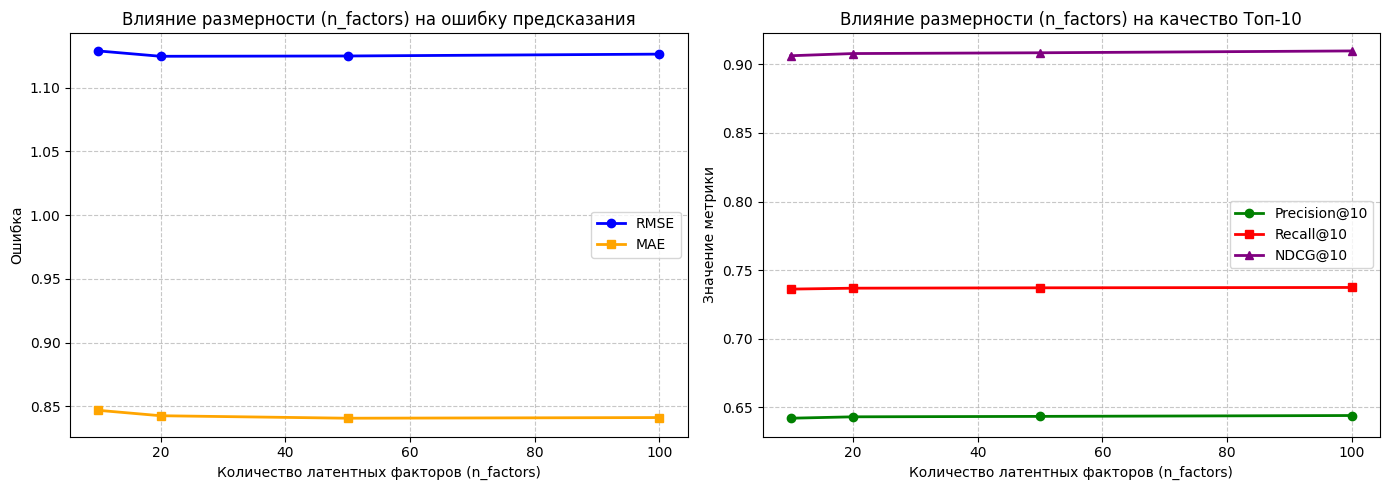

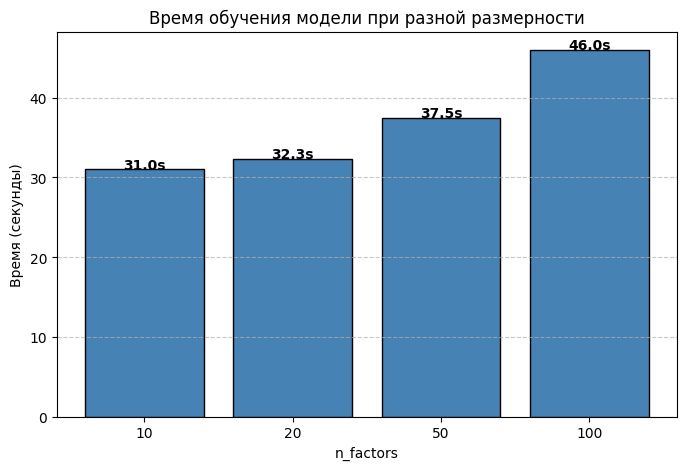

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# график 1 метрики регрессии
axes[0].plot(results_df['n_factors'], results_df['RMSE'], marker='o', color='blue', label='RMSE', linewidth=2)
axes[0].plot(results_df['n_factors'], results_df['MAE'], marker='s', color='orange', label='MAE', linewidth=2)
axes[0].set_title('Влияние размерности (n_factors) на ошибку предсказания', fontsize=12)
axes[0].set_xlabel('Количество латентных факторов (n_factors)')
axes[0].set_ylabel('Ошибка')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# график 2 метрики ранжирования
axes[1].plot(results_df['n_factors'], results_df['Precision@10'], marker='o', color='green', label='Precision@10', linewidth=2)
axes[1].plot(results_df['n_factors'], results_df['Recall@10'], marker='s', color='red', label='Recall@10', linewidth=2)
axes[1].plot(results_df['n_factors'], results_df['NDCG@10'], marker='^', color='purple', label='NDCG@10', linewidth=2)
axes[1].set_title('Влияние размерности (n_factors) на качество Топ-10', fontsize=12)
axes[1].set_xlabel('Количество латентных факторов (n_factors)')
axes[1].set_ylabel('Значение метрики')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# дополнительно график времени обучения
plt.figure(figsize=(8, 5))
plt.bar(results_df['n_factors'].astype(str), results_df['train_time_sec'], color='steelblue', edgecolor='black')
plt.title('Время обучения модели при разной размерности', fontsize=12)
plt.xlabel('n_factors')
plt.ylabel('Время (секунды)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(results_df['train_time_sec']):
    plt.text(i, v + 0.1, f'{v:.1f}s', ha='center', fontweight='bold')
plt.show()